<a href="https://colab.research.google.com/github/mathgenhigh/AI-stuff/blob/main/PracticeList3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

In [74]:
# Task 2 -> Parser
import numpy as np

def load_xy(path):
    data = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("i"):
                continue
            x_str, y_str = line.split()
            data.append([float(x_str), float(y_str)])
    return np.array(data)

In [70]:
s1 = load_xy("s1.txt")
print(s1)

[[664159. 550946.]
 [665845. 557965.]
 [597173. 575538.]
 ...
 [650661. 861267.]
 [599647. 858702.]
 [684091. 842566.]]


In [71]:
s2 = load_xy("s2.txt")

In [72]:
s3 = load_xy("s3.txt")

In [75]:
s4 = load_xy("s4.txt")

In [79]:
# Task 3

# s1.txt:
# - Pattern: Several dense blobs in different coordinate ranges:
#   - Mid‑range cluster around (600,550) (e.g. 664159 550946, 618600 551446).
#   - Later, a block around (800,320) (e.g. 801539 318482, 814045 332998).
#   - Later, a block around (400,800) (e.g. 378274 816341, 448651 847994).
#   - And finally a block around (860,160) (e.g. 860951 162251, 857363 154639).
# - Effect on clustering: Fairly “blob‑like” clusters, but with different scales and densities. K‑means is quite suitable here; main issues are:
#   - Choosing K: You likely want K≈4 for the big groups.
#   - Initialization: Poor init can split one blob or merge two nearby ones.

# s2.txt
# - Pattern: Also multiple regions, but more elongated and noisy:
#   - High‑value clusters around (840,630) (e.g. 845753 636607, 868217 609046).
#   - A mid‑range block around (560,250) (e.g. 623573 252933, 569298 222324).
#   - A large block around (260,740) (e.g. 256910 767396, 254116 748223).
#   - Another around (560,440) (e.g. 581344 385622, 531520 470380).
#   - And finally around (800,240) (e.g. 793712 253869, 824235 182393).
# - Effect on clustering:
#   - Clusters are more elongated and sometimes overlapping.
#   - K‑means (which assumes roughly spherical clusters in Euclidean space) will approximate these with circular Voronoi regions, so boundaries may cut through elongated structures.

# s3.txt
# - Pattern: Similar multi‑block structure, but with:
#   - A big central-ish cloud around (520,600) (e.g. 520651 594591, 588509 666153).
#   - A lower block around (540,300) (e.g. 569835 305861, 532938 306366).
#   - A mid block around (250,350) (e.g. 264404 357298, 228386 347570).
#   - A block around (450,400) (e.g. 397836 451809, 465078 380683).
#   - And a high block around (780,800) (e.g. 824024 787559, 789530 721998).
# - Effect on clustering:
#   - More clusters, more overlap, and some with similar scales.
#   - K‑means will still find reasonable centroids, but:
#   - Cluster separation is weaker.
#   - Cluster count is less obvious; elbow/silhouette methods become more important.

# s4.txt
# - Pattern: Very similar idea: multiple clouds at different scales and positions,
#   but with more noise and some outliers (you can see odd lines like it'son purpose embedded).
# - Effect on clustering:
#   - Outliers and noise can pull centroids away from dense cores.
#   - You may want to:
#     - Clean data (remove non‑numeric lines, extreme outliers).
#     - Consider robust variants or pre‑filtering before K‑means.

In [80]:
# Task 4 -> KMeans
def run_kmeans(X, K, init_method="k-means++", n_init=20):
    model = KMeans(
        n_clusters=K,
        init=init_method,
        n_init=n_init,
        random_state=0
    )
    model.fit(X)
    return model.labels_, model.cluster_centers_, model.inertia_

def plot_clusters(X, labels, centers, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap="tab10")
    plt.scatter(centers[:, 0], centers[:, 1], c="black", s=200, marker="X")
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

def process_dataset(name, K):
    print(f"\n=== Dataset: {name} | K = {K} ===")

    X = load_xy(f"{name}.txt")

    # Try two initialization strategies
    for init_method in ["k-means++", "random"]:
        labels, centers, inertia = run_kmeans(
            X, K, init_method=init_method, n_init=20
        )

        print(f"Init: {init_method:10s} | Inertia: {inertia:.2f}")

        plot_clusters(
            X,
            labels,
            centers,
            title=f"{name.upper()} — init={init_method}"
        )


=== Dataset: s1 | K = 4 ===
Init: k-means++  | Inertia: 138251040835056.91


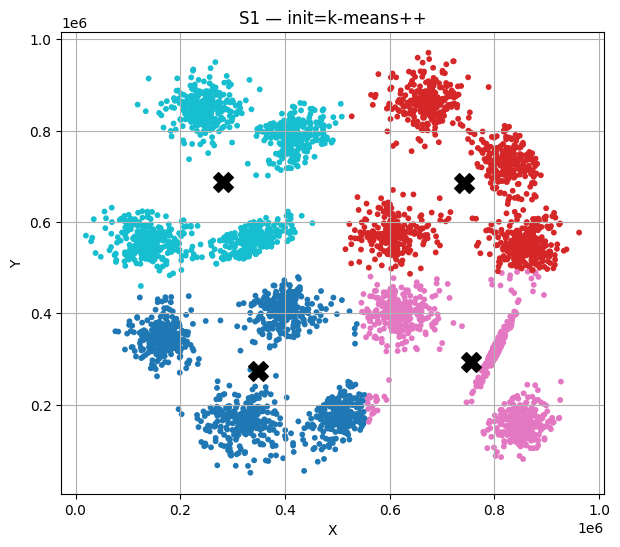

Init: random     | Inertia: 138251485155489.39


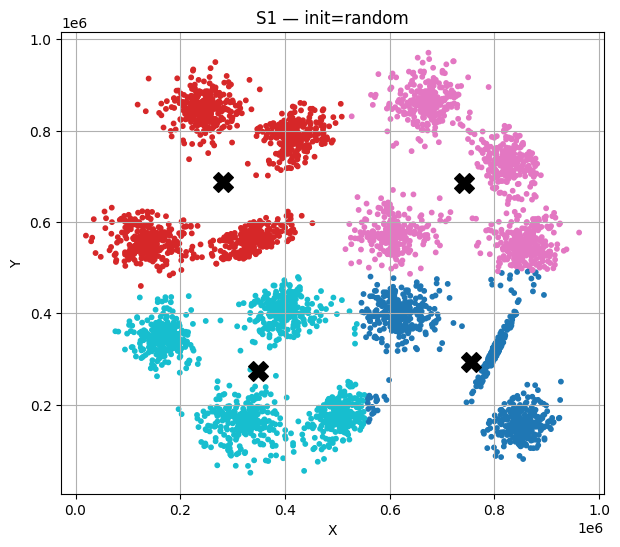


=== Dataset: s2 | K = 5 ===
Init: k-means++  | Inertia: 97167660541094.28


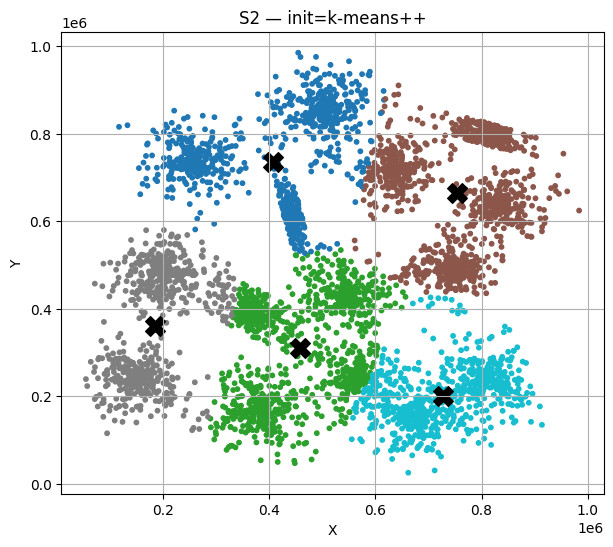

Init: random     | Inertia: 97169900277715.89


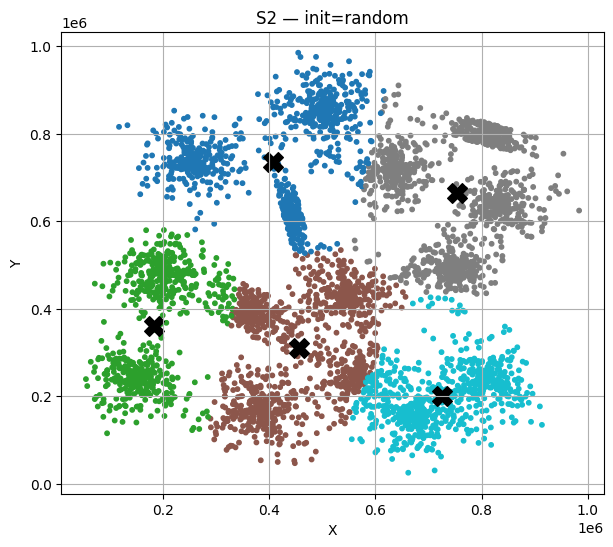


=== Dataset: s3 | K = 6 ===
Init: k-means++  | Inertia: 61402157346556.30


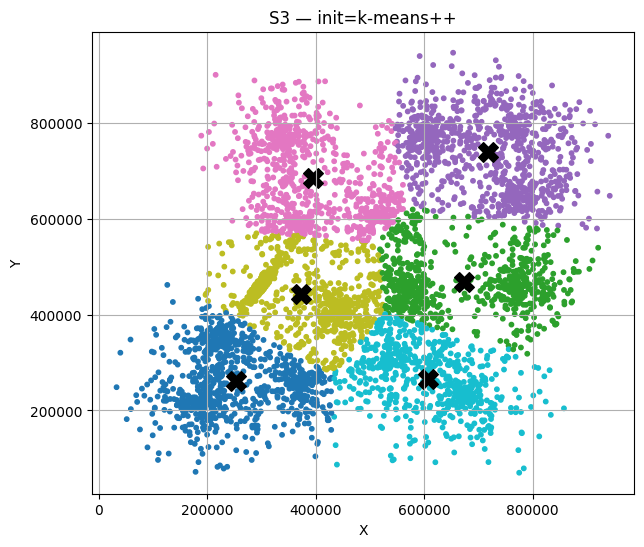

Init: random     | Inertia: 61403195944252.52


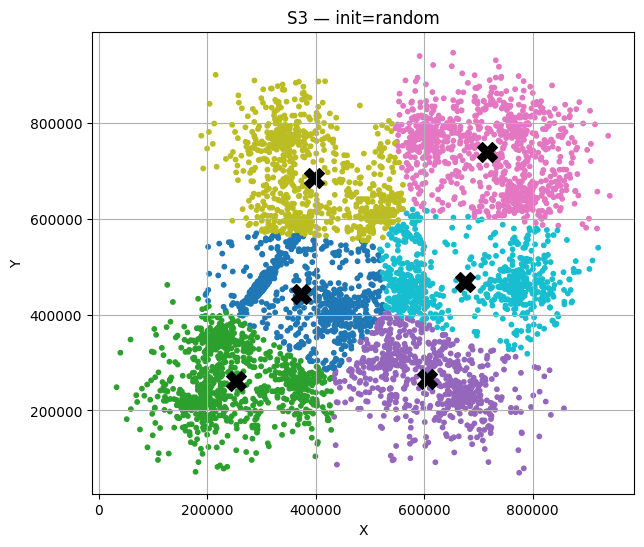


=== Dataset: s4 | K = 6 ===
Init: k-means++  | Inertia: 51922713998725.80


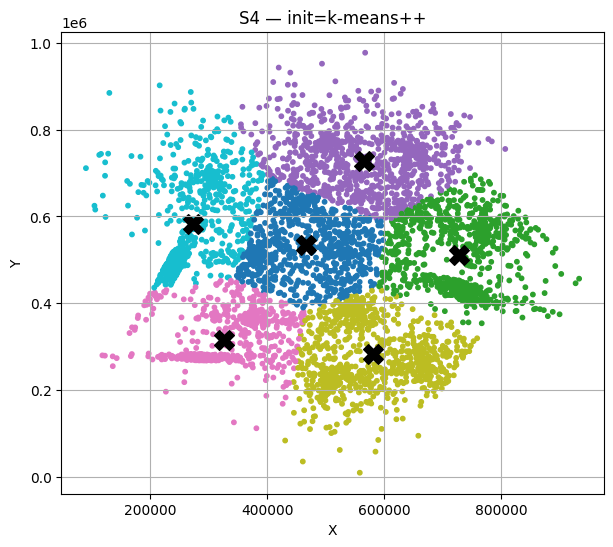

Init: random     | Inertia: 52708955991952.10


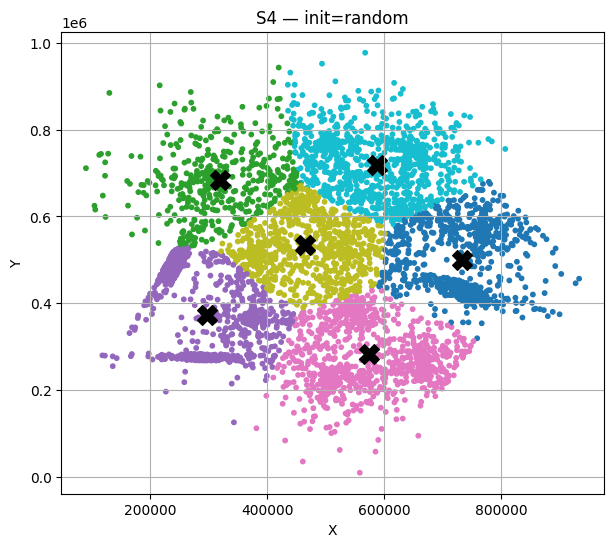

In [82]:
Ks = {
        "s1": 4,
        "s2": 5,
        "s3": 6,
        "s4": 6
    }

for dataset, K in Ks.items():
    process_dataset(dataset, K)

Key Takeaways

    K‑means works best when clusters are:

        convex

        spherical

        similar in size

        well-separated

    K‑means struggles when clusters are:

        elongated

        curved

        overlapping

        noisy

        non-convex

    Initialization matters:

        k-means++ is more stable

        random can produce poor solutions

    s1 is a textbook example where K‑means shines.

    s4 is a textbook example where K‑means fails. *Курсив*

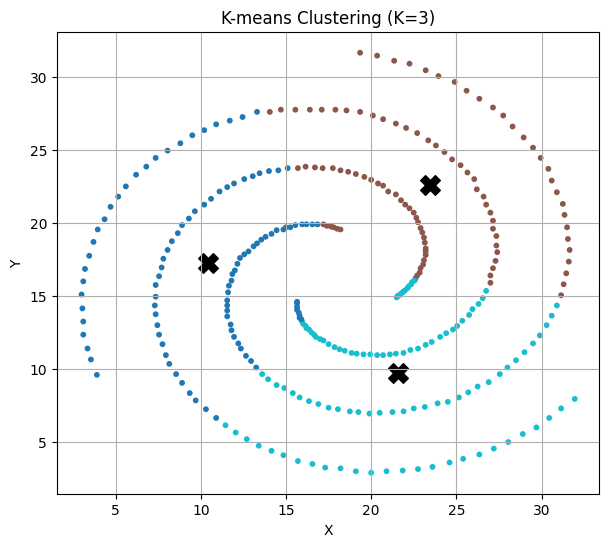

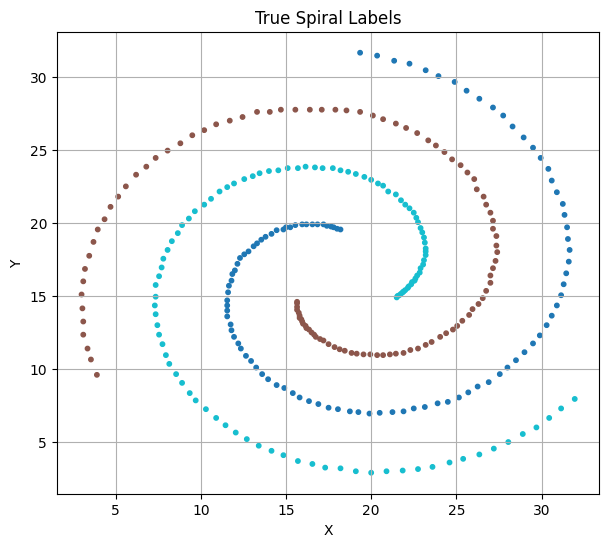

In [85]:
# Task 6
def load_spiral(path):
    X = []
    y = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 3:
                continue
            x, y_, label = parts
            X.append([float(x), float(y_)])
            y.append(int(label))
    return np.array(X), np.array(y)

def run_kmeans_spiral(X, K=3):
    model = KMeans(
        n_clusters=K,
        init="k-means++",
        n_init=20,
        random_state=0
    )
    model.fit(X)
    return model.labels_, model.cluster_centers_


def plot_spiral(X, labels, centers, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap="tab10")
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], c="black", s=200, marker="X")
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

X, y_true = load_spiral("spiral.txt")

# Run K-means
y_pred, centers = run_kmeans_spiral(X, K=3)

# Plot K-means result
plot_spiral(X, y_pred, centers, "K-means Clustering (K=3)")

# Plot true labels
plot_spiral(X, y_true, None, "True Spiral Labels")

Why K‑means Fails on the Spiral

1. Non‑convex shape

Spiral arms curve around each other.
K‑means cannot represent curved shapes.

2. Intertwined clusters

Points from different arms are often close in Euclidean distance.
K‑means groups by distance to centroid, not by shape.

3. Centroids are misleading

Each spiral arm wraps around the center.
The centroid ends up in the middle, far from the actual arm.

4. Straight-line boundaries

K‑means partitions space using straight lines.
Spirals require curved boundaries.


Correct Interpretation

True labels

    Perfectly separate the three spiral arms

    Reflect the actual structure of the data

K‑means labels

    Incorrect

    Artificially slice the spiral into radial sectors

    Do not correspond to the true clusters

What Works Better Than K‑means?

For non‑convex shapes like spirals, use:

    Spectral Clustering

    DBSCAN

    Agglomerative Clustering (single-linkage)

    HDBSCAN

These methods can follow curved, irregular shapes.